In [1]:
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
# import Polygon from shapely
from shapely.geometry import Polygon
import rasterstats 
import geopandas as gpd
import pandas as pd
import rasterio

In [2]:
ds = xr.open_dataset("/scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/forcing/merged_data/ERA5_merged_201704.nc")
# gdf = pd.read_csv("/scratch/dlhogan/ess-project-data/domain_East_River_distributed/shapefiles/catchment_intersection/with_forcing/East_River_distributed_ERA5_intersected_shapefile.csv")
# gdf2 = gpd.read_file("/scratch/dlhogan/ess-project-data/domain_East_River_distributed/shapefiles/catchment_intersection/with_soilgrids/catchment_with_soilclass.shp")

In [14]:
# set file path to storage
storage_path = Path("/scratch/dlhogan/ess-project-data/domain_butte_snotel/forcing/SUMMA_input")

In [6]:
# iterate through the files in the storage path
files_to_remove_for_variable_issues = []
files_to_remove_for_file_opening_issues = []
for file in storage_path.glob("ERA5_surface_*.nc"):
    # test if the file can be opened
    try:
        ds = xr.open_dataset(file)
        # if successful, test if the file has more than 1 variable
        if len(ds.data_vars) > 1:
            continue  # skip files with more than 1 variable
        else:
            files_to_remove_for_variable_issues.append(file)
    except Exception as e:
        # if an error occurs, add the file to the list for file opening issues
        files_to_remove_for_file_opening_issues.append(file)

In [7]:
len(files_to_remove_for_variable_issues), len(files_to_remove_for_file_opening_issues)

(0, 0)

In [43]:
# now move each of these files to the /archive directory
archive_path = storage_path / "archive"
archive_path.mkdir(exist_ok=True)

for file in files_to_remove_for_variable_issues + files_to_remove_for_file_opening_issues:
    file.rename(archive_path / file.name)
    print(f"Moved {file.name} to archive.")

Moved ERA5_surface_200001.nc to archive.
Moved ERA5_surface_200002.nc to archive.
Moved ERA5_surface_200101.nc to archive.
Moved ERA5_surface_200102.nc to archive.
Moved ERA5_surface_200103.nc to archive.
Moved ERA5_surface_200201.nc to archive.
Moved ERA5_surface_200202.nc to archive.
Moved ERA5_surface_200301.nc to archive.
Moved ERA5_surface_200302.nc to archive.
Moved ERA5_surface_200303.nc to archive.
Moved ERA5_surface_200401.nc to archive.
Moved ERA5_surface_200402.nc to archive.
Moved ERA5_surface_200308.nc to archive.
Moved ERA5_surface_200012.nc to archive.
Moved ERA5_surface_199712.nc to archive.
Moved ERA5_surface_200009.nc to archive.
Moved ERA5_surface_200210.nc to archive.
Moved ERA5_surface_200311.nc to archive.
Moved ERA5_surface_200109.nc to archive.
Moved ERA5_surface_200312.nc to archive.
Moved ERA5_surface_199912.nc to archive.
Moved ERA5_surface_199811.nc to archive.
Moved ERA5_surface_200410.nc to archive.
Moved ERA5_surface_199810.nc to archive.
Moved ERA5_surfa

In [16]:
# compare forcing datasets
storage_path_2 = Path("/storage/dlhogan/ess_project_data/domain_East_River/forcing/basin_averaged_data")
ds_original = xr.open_dataset(storage_path_2 / "East_River_ERA5_remapped_domain_East_River_ERA5_merged_198104.nc")
ds_new = xr.open_dataset(storage_path / "butte_snotel_ERA5_remapped_ERA5_merged_198104.nc")

ds_not_merged = xr.open_dataset("/scratch/dlhogan/ess-project-data/domain_butte_snotel/forcing/raw_data/ERA5_pressureLevel137_198101.nc")

In [5]:
# testing the creation of the era5 shapefile
forcing_ds = xr.open_dataset("/scratch/dlhogan/ess-project-data/domain_butte_snotel/forcing/merged_data/ERA5_merged_198101.nc")
# Set the dimension variable names
source_name_lat = "latitude"
source_name_lon = "longitude"

lat = forcing_ds[source_name_lat].values
lon = forcing_ds[source_name_lon].values

print(f"ERA5 dimensions: lat={lat.shape}, lon={lon.shape}")

half_dlat = abs(lat[1] - lat[0])/2 if len(lat) > 1 else 0.125  # Default to 0.25/2 if only one value
half_dlon = abs(lon[1] - lon[0])/2 if len(lon) > 1 else 0.125  # Default to 0.25/2 if only one value

print(f"ERA5 grid spacings: half_dlat={half_dlat}, half_dlon={half_dlon}")

# Create lists to store the data
geometries = []
ids = []
lats = []
lons = []

ERA5 dimensions: lat=(5,), lon=(5,)
ERA5 grid spacings: half_dlat=0.125, half_dlon=0.125


In [6]:
if len(lat) == 1:
    print("Single latitude value detected, creating row of grid cells")
    for i, center_lon in enumerate(lon):
        center_lat = lat[0]
        vertices = [
            [float(center_lon)-half_dlon, float(center_lat)-half_dlat],
            [float(center_lon)-half_dlon, float(center_lat)+half_dlat],
            [float(center_lon)+half_dlon, float(center_lat)+half_dlat],
            [float(center_lon)+half_dlon, float(center_lat)-half_dlat],
            [float(center_lon)-half_dlon, float(center_lat)-half_dlat]
        ]
        geometries.append(Polygon(vertices))
        ids.append(i)
        lats.append(float(center_lat))
        lons.append(float(center_lon))
else:
    print("Multiple latitude values, creating grid")
    for i, center_lon in enumerate(lon):
        for j, center_lat in enumerate(lat):
            vertices = [
                [float(center_lon)-half_dlon, float(center_lat)-half_dlat],
                [float(center_lon)-half_dlon, float(center_lat)+half_dlat],
                [float(center_lon)+half_dlon, float(center_lat)+half_dlat],
                [float(center_lon)+half_dlon, float(center_lat)-half_dlat],
                [float(center_lon)-half_dlon, float(center_lat)-half_dlat]
            ]
            geometries.append(Polygon(vertices))
            ids.append(i * len(lat) + j)
            lats.append(float(center_lat))
            lons.append(float(center_lon))
                
print(f"Created {len(geometries)} grid cell geometries")

Multiple latitude values, creating grid
Created 25 grid cell geometries


In [7]:
gdf = gpd.GeoDataFrame({
                    'geometry': geometries,
                    'ID': ids,
                    'latitude': lats,
                    'longitude': lons,
                }, crs='EPSG:4326')

In [11]:
dem_path = Path("/scratch/dlhogan/ess-project-data/domain_butte_snotel/attributes/elevation/dem") 

elevations = [-9999] * len(gdf)

# Get CRS information
with rasterio.open(dem_path / "domain_butte_snotel_elv.tif") as src:
    dem_crs = src.crs
    print(f"DEM CRS: {dem_crs}")
    shapefile_crs = gdf.crs
    print(f"Shapefile CRS: {shapefile_crs}")

gdf_projected = gdf.copy()

batch_size = 20
num_batches = (len(gdf_projected) + batch_size - 1) // batch_size
for batch_idx in range(num_batches):
    start_idx = batch_idx * batch_size
    end_idx = min(start_idx + batch_size, len(gdf_projected))
    # Get batch of geometries
    batch_gdf = gdf_projected.iloc[start_idx:end_idx]
    
    # Use rasterstats with the raster file path directly (more efficient and handles CRS properly)
    zs = rasterstats.zonal_stats(
        batch_gdf.geometry, 
        str(dem_path / "domain_butte_snotel_elv.tif"),  # Use file path instead of array
        stats=['mean'],
        nodata=-9999  # Explicit nodata value
    )
    
    # Update elevation values
    for i, item in enumerate(zs):
        idx = start_idx + i
        elevations[idx] = item['mean'] if item['mean'] is not None else -9999
    print(f"Processed batch {batch_idx + 1}/{num_batches}")
valid_elevations = sum(1 for elev in elevations if elev != -9999)
print(f"Successfully calculated elevation for {valid_elevations}/{len(elevations)} geometries")

DEM CRS: EPSG:4326
Shapefile CRS: EPSG:4326
Processed batch 1/2
Processed batch 2/2
Successfully calculated elevation for 25/25 geometries


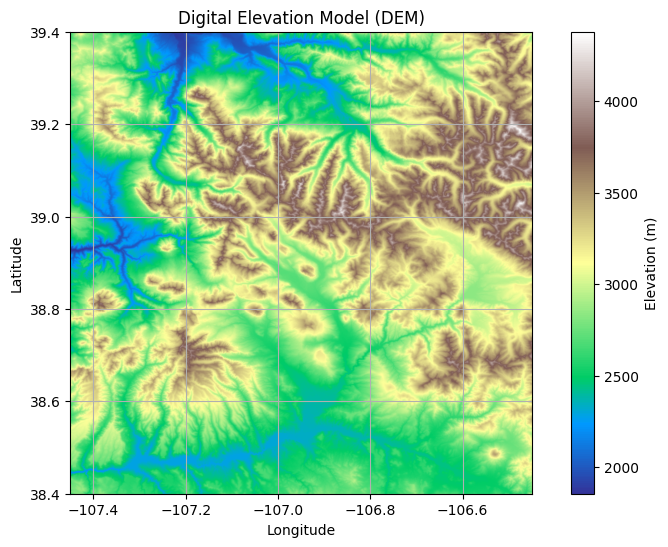

In [18]:

# plot the DEM
with rasterio.open("/scratch/dlhogan/ess-project-data/domain_butte_snotel/attributes/elevation/dem/domain_butte_snotel_elv.tif") as src:
    dem_data = src.read(1)
    # dem_transform = src.transform

plt.figure(figsize=(10, 6))
plt.title("Digital Elevation Model (DEM)")
plt.imshow(dem_data, cmap='terrain', extent=(src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top))
plt.colorbar(label="Elevation (m)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

In [13]:
gds = xr.open_dataset("/scratch/dlhogan/ess-project-data/domain_butte_snotel/shapefiles/catchment_intersection/with_forcing/butte_snotel_ERA5_remapping.nc")
gds[['S_1_elev_mean','S_2_elev_m']].to_pandas()

,S_1_elev_mean,S_2_elev_m
frequency,,
0,2957.136711,2822.814596
1,2957.136711,2666.129004
2,2957.136711,2540.505191
3,2957.136711,2953.917460
4,2957.136711,3047.900066
5,2957.136711,2905.579623
6,2957.136711,2359.067996
7,2957.136711,2733.546844
8,2957.136711,3363.180155


In [4]:
df = pd.read_csv('/scratch/dlhogan/ess-project-data/domain_butte_snotel/shapefiles/catchment_intersection/with_forcing/butte_snotel_ERA5_intersected_shapefile.csv')

# where S_2_elev_m == -9999 replace with S_1_elev_m value
df['S_2_elev_m'] = df['S_2_elev_m'].astype(float)
df.loc[df['S_2_elev_m'] == -9999., 'S_2_elev_m'] = df['S_1_elev_m']

df[['S_1_elev_m','S_2_elev_m']]

FileNotFoundError: [Errno 2] No such file or directory: '/scratch/dlhogan/ess-project-data/domain_butte_snotel/shapefiles/catchment_intersection/with_forcing/butte_snotel_ERA5_intersected_shapefile.csv'

Variable latitude not found in new dataset.
Variable longitude not found in new dataset.
Variable hruId not found in new dataset.
Variable spechum not found in new dataset.
Variable windspd not found in new dataset.


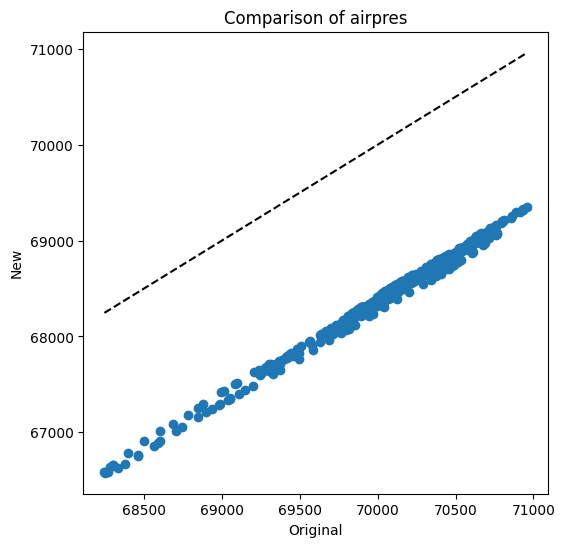

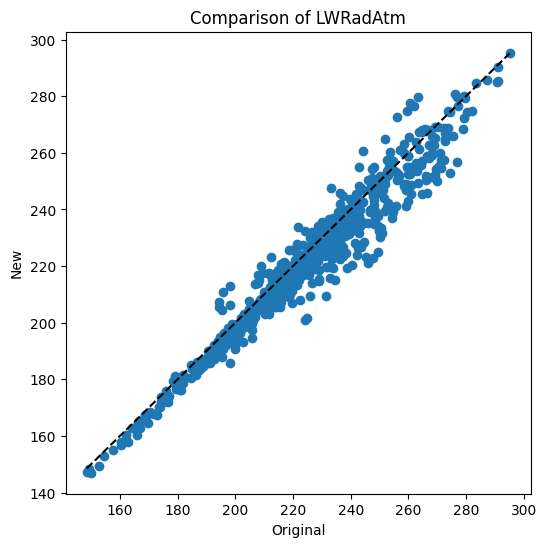

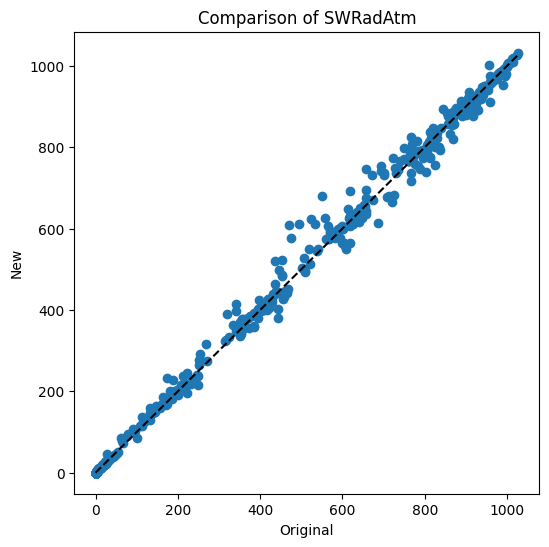

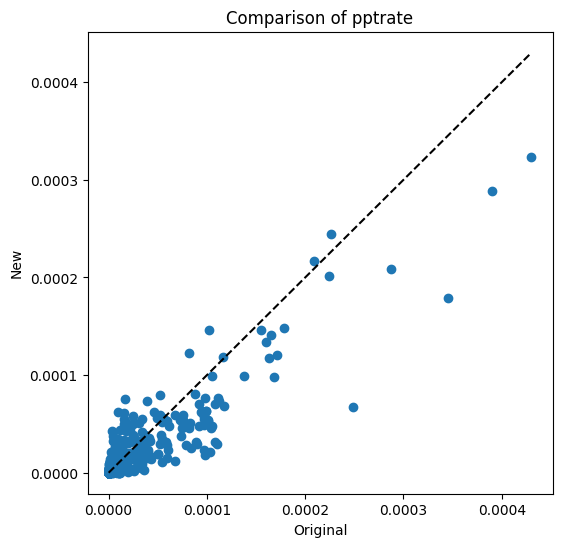

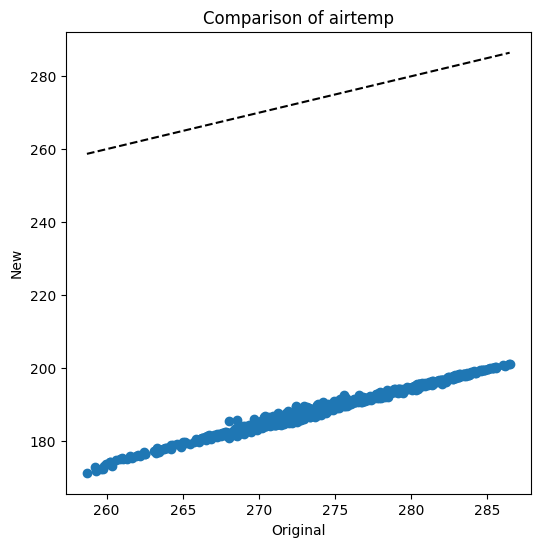

In [14]:
# compare each variable in the datasets
for var in ds_original.data_vars:
    if var in ['airpres', 'LWRadAtm', 'SWRadAtm', 'pptrate', 'airtemp']:
        plt.figure(figsize=(6, 6))
        plt.scatter(ds_original[var].values, ds_new[var].values)
        plt.plot([ds_original[var].min(), ds_original[var].max()], [ds_original[var].min(), ds_original[var].max()], 'k--')
        plt.xlabel("Original")
        plt.ylabel("New")
        plt.title(f"Comparison of {var}")
    else:
        print(f"Variable {var} not found in new dataset.")